In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

conn = sqlite3.connect("../data/processed/market_data.db")
eq_df = pd.read_sql("SELECT * FROM equities_daily", conn, 
                    index_col="date", parse_dates=["date"])

# Returns mensuels
monthly_ret = eq_df.resample("ME").last().pct_change().dropna()

print("✅ Données chargées")
print(monthly_ret.tail(3))


✅ Données chargées
                 SPY       XLB       XLC       XLE       XLF       XLI  \
date                                                                     
2024-10-31 -0.008924 -0.031023  0.018142  0.008998  0.025596 -0.011887   
2024-11-30  0.059633  0.014884  0.069100  0.078338  0.104561  0.075917   
2024-12-31 -0.020497 -0.111236 -0.010340 -0.107513 -0.055592 -0.079215   

                 XLK       XLP      XLRE       XLU       XLV       XLY  
date                                                                    
2024-10-31 -0.015592 -0.034699 -0.032908 -0.010770 -0.046423 -0.017368  
2024-11-30  0.051701  0.038692  0.041667  0.037792  0.003677  0.129057  
2024-12-31  0.004810 -0.051134 -0.093690 -0.078890 -0.064776  0.018796  


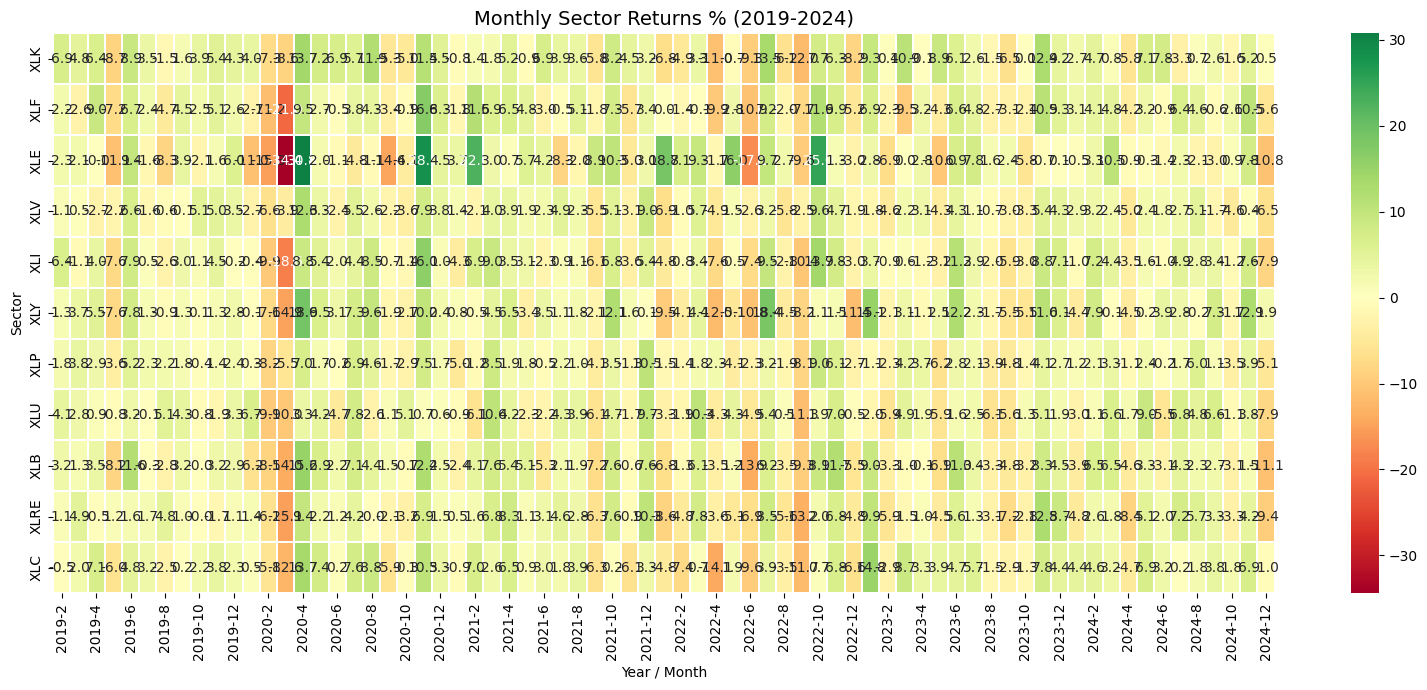

✅ Sector heatmap sauvegardée


In [2]:
# Secteurs uniquement (sans SPY)
sectors = ["XLK","XLF","XLE","XLV","XLI","XLY","XLP","XLU","XLB","XLRE","XLC"]
sector_ret = monthly_ret[sectors] * 100  # En pourcentage

# Pivot : années en index, mois en colonnes
sector_ret.index = pd.MultiIndex.from_arrays([
    sector_ret.index.year,
    sector_ret.index.month
])

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(
    sector_ret.T,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.3,
    ax=ax
)
ax.set_title("Monthly Sector Returns % (2019-2024)", fontsize=14)
ax.set_xlabel("Year / Month")
ax.set_ylabel("Sector")
plt.tight_layout()
plt.savefig("../output/charts/sector_heatmap.png", dpi=150)
plt.show()
print("✅ Sector heatmap sauvegardée")


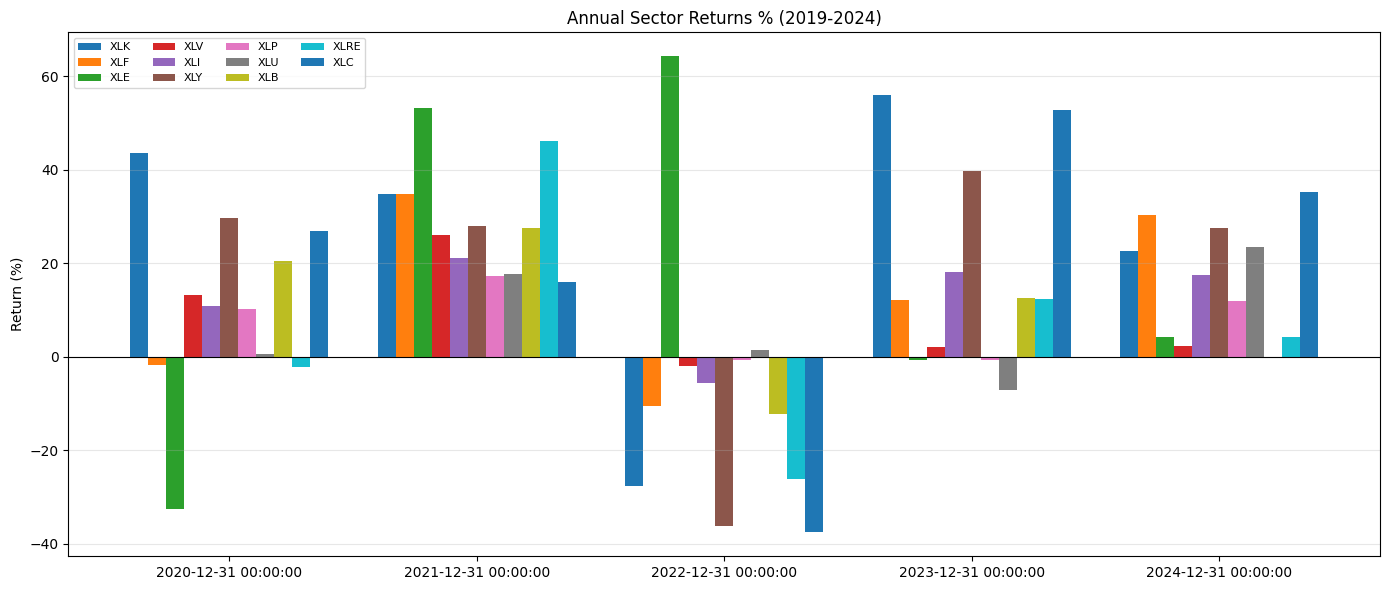

✅ Annual returns sauvegardé


In [3]:
annual_ret = eq_df.resample("YE").last().pct_change().dropna() * 100

fig, ax = plt.subplots(figsize=(14, 6))
annual_ret[sectors].plot(kind="bar", ax=ax, width=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Annual Sector Returns % (2019-2024)")
ax.set_ylabel("Return (%)")
ax.set_xlabel("")
ax.legend(loc="upper left", fontsize=8, ncol=4)
ax.grid(True, alpha=0.3, axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../output/charts/annual_sector_returns.png", dpi=150)
plt.show()
print("✅ Annual returns sauvegardé")
